In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
import sys
# add the project root to the path so the src package can be imported
sys.path.append(os.path.abspath('..'))

from torch import load,device,tensor
import torch.nn.functional as F
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import yaml
from src.model_utils import get_transforms,denorm,FocalLoss,build_swin_model,predict_classifier
from src.train_classifier import train
from src.vis import show_curves,show_confusion_matrix


In [3]:
with open('../configs/stage3.yaml','r') as f:

    stage3_config = yaml.safe_load(f)

with open(stage3_config['paths']['data_yaml_path'],'r') as f:

    dis_data_yaml = yaml.safe_load(f)

with open('../configs/trained_models.yaml','r') as f:

    trained_models_config = yaml.safe_load(f)

In [4]:
stage3_config

{'paths': {'original_images_path': '../Data/Raw/DENTEX CHALLENGE 2023/Training_data/quadrant-enumeration-disease/xrays',
  'original_json_path': '../Data/Raw/DENTEX CHALLENGE 2023/Training_data/quadrant-enumeration-disease/train_quadrant_enumeration_disease.json',
  's3_main_path': '../Data/Processed/Stage 3 (Disease Classifier)',
  'runs_s3_output': '../Runs/Stage 3',
  'data_yaml_path': '../Data/Processed/Stage 3 (Disease Classifier)/data.yaml'},
 'healthy_unhealthy': {'model_args': {'image_size': 256,
   'epochs': 15,
   'batch_size': 64,
   'patience': 5,
   'lr': 0.0001,
   'drop_out': 0.4,
   'num_workers': 4,
   'device_name': 'cuda',
   'save_dir': '../Runs/Stage 3/healthy_unhealthy'}},
 'disease_classifier': {'model_args': {'image_size': 256,
   'epochs': 25,
   'batch_size': 64,
   'patience': 7,
   'lr': 0.0001,
   'drop_out': 0.4,
   'num_workers': 4,
   'device_name': 'cuda',
   'save_dir': '../Runs/Stage 3/disease_classifier'}},
 'caries_or_deepcaries': {'model_args': {'i

In [5]:
dis_data_yaml

{'healthy_unhealthy': {'train': '../Data/Processed/Stage 3 (Disease Classifier)/healthy or un-healthy classifier/train/',
  'val': '../Data/Processed/Stage 3 (Disease Classifier)/healthy or un-healthy classifier/valid/',
  'test': '../Data/Processed/Stage 3 (Disease Classifier)/healthy or un-healthy classifier/test/',
  'nc': 2,
  'names': ['Disease Found', 'Healthy']},
 'disease_classifier': {'train': '../Data/Processed/Stage 3 (Disease Classifier)/disease classifier/train/',
  'val': '../Data/Processed/Stage 3 (Disease Classifier)/disease classifier/valid/',
  'test': '../Data/Processed/Stage 3 (Disease Classifier)/disease classifier/test/',
  'nc': 3,
  'names': ['Impacted', 'Caries', 'Periapical']},
 'caries_or_deepcaries': {'train': '../Data/Processed/Stage 3 (Disease Classifier)/caries or deep_caries classifier/train/',
  'val': '../Data/Processed/Stage 3 (Disease Classifier)/caries or deep_caries classifier/valid/',
  'test': '../Data/Processed/Stage 3 (Disease Classifier)/carie

In [6]:
trained_models_config

{'quadrant_detection_model': {'best': '../Runs/Stage 1/weights/best.pt',
  'last': '../Runs/Stage 1/weights/last.pt'},
 'enumeration_detection_model': {'best': '../Runs/Stage 2/weights/best.pt',
  'last': '../Runs/Stage 2/weights/last.pt'},
 'enumeration_continued_detection_model': {'best': '../Runs/Stage 2 Continued/weights/best.pt',
  'last': '../Runs/Stage 2 Continued/weights/last.pt'},
 'healthy_unhealthy_model': {'best': '../Runs/Stage 3/Healthy & Un-Healthy Classifier/weights/best.pt',
  'last': '../Runs/Stage 3/Healthy & Un-Healthy Classifier/weights/last.pt'},
 'disease_classification_model': {'best': '../Runs/Stage 3/Disease Classifier/weights/best.pt',
  'last': '../Runs/Stage 3/Disease Classifier/weights/last.pt'},
 'caries_deepcaries_model': {'best': '../Runs/Stage 3/Caries & Deep Caries Classifier/weights/best.pt',
  'last': '../Runs/Stage 3/Caries & Deep Caries Classifier/weights/last.pt'},
 'final_recommended_models': {'quadrant_model': '../Runs/Stage 1/weights/last.pt',

In [7]:
H_UH_CONFIG = stage3_config['healthy_unhealthy']['model_args']
DIS_CONFIG = stage3_config['disease_classifier']['model_args']
C_DC_CONFIG = stage3_config['caries_or_deepcaries']['model_args']

In [8]:
h_uh_train_dataset = ImageFolder(dis_data_yaml['healthy_unhealthy']['train'], transform = get_transforms(H_UH_CONFIG['image_size'], True))
h_uh_valid_dataset = ImageFolder(dis_data_yaml['healthy_unhealthy']['val']  , transform = get_transforms(H_UH_CONFIG['image_size']))
h_uh_test_dataset  = ImageFolder(dis_data_yaml['healthy_unhealthy']['test'] , transform = get_transforms(H_UH_CONFIG['image_size']))

h_uh_train_dl = DataLoader(h_uh_train_dataset, batch_size=H_UH_CONFIG['batch_size'], shuffle=True , num_workers=H_UH_CONFIG['num_workers'], pin_memory=True)
h_uh_valid_dl = DataLoader(h_uh_valid_dataset, batch_size=H_UH_CONFIG['batch_size'], shuffle=False, num_workers=H_UH_CONFIG['num_workers'], pin_memory=True)
h_uh_test_dl  = DataLoader(h_uh_test_dataset , batch_size=H_UH_CONFIG['batch_size'], shuffle=False, num_workers=H_UH_CONFIG['num_workers'], pin_memory=True)
print(h_uh_train_dataset.classes)

['1_disease found', '2_no disease found']


In [8]:
dis_train_dataset = ImageFolder(dis_data_yaml['disease_classifier']['train'], transform = get_transforms(DIS_CONFIG['image_size'],True))
dis_valid_dataset = ImageFolder(dis_data_yaml['disease_classifier']['val']  , transform = get_transforms(DIS_CONFIG['image_size']))
dis_test_dataset  = ImageFolder(dis_data_yaml['disease_classifier']['test'] , transform = get_transforms(DIS_CONFIG['image_size']))

dis_train_dl = DataLoader(dis_train_dataset, batch_size=DIS_CONFIG['batch_size'], shuffle=True , num_workers=DIS_CONFIG['num_workers'], pin_memory=True)
dis_valid_dl = DataLoader(dis_valid_dataset, batch_size=DIS_CONFIG['batch_size'], shuffle=False, num_workers=DIS_CONFIG['num_workers'], pin_memory=True)
dis_test_dl  = DataLoader(dis_test_dataset , batch_size=DIS_CONFIG['batch_size'], shuffle=False, num_workers=DIS_CONFIG['num_workers'], pin_memory=True)
print(dis_train_dataset.classes)

['0_impacted', '1_caries', '2_periapical']


In [9]:
c_dc_train_dataset = ImageFolder(dis_data_yaml['caries_or_deepcaries']['train'], transform = get_transforms(C_DC_CONFIG['image_size'],True))
c_dc_valid_dataset = ImageFolder(dis_data_yaml['caries_or_deepcaries']['val']  , transform = get_transforms(C_DC_CONFIG['image_size']))
c_dc_test_dataset  = ImageFolder(dis_data_yaml['caries_or_deepcaries']['test'] , transform = get_transforms(C_DC_CONFIG['image_size']))

c_dc_train_dl = DataLoader(c_dc_train_dataset, batch_size=C_DC_CONFIG['batch_size'], shuffle=True , num_workers=C_DC_CONFIG['num_workers'], pin_memory=True)
c_dc_valid_dl = DataLoader(c_dc_valid_dataset, batch_size=C_DC_CONFIG['batch_size'], shuffle=False, num_workers=C_DC_CONFIG['num_workers'], pin_memory=True)
c_dc_test_dl  = DataLoader(c_dc_test_dataset , batch_size=C_DC_CONFIG['batch_size'], shuffle=False, num_workers=C_DC_CONFIG['num_workers'], pin_memory=True)
print(c_dc_train_dataset.classes)

['1_caries', '2_deep caries']


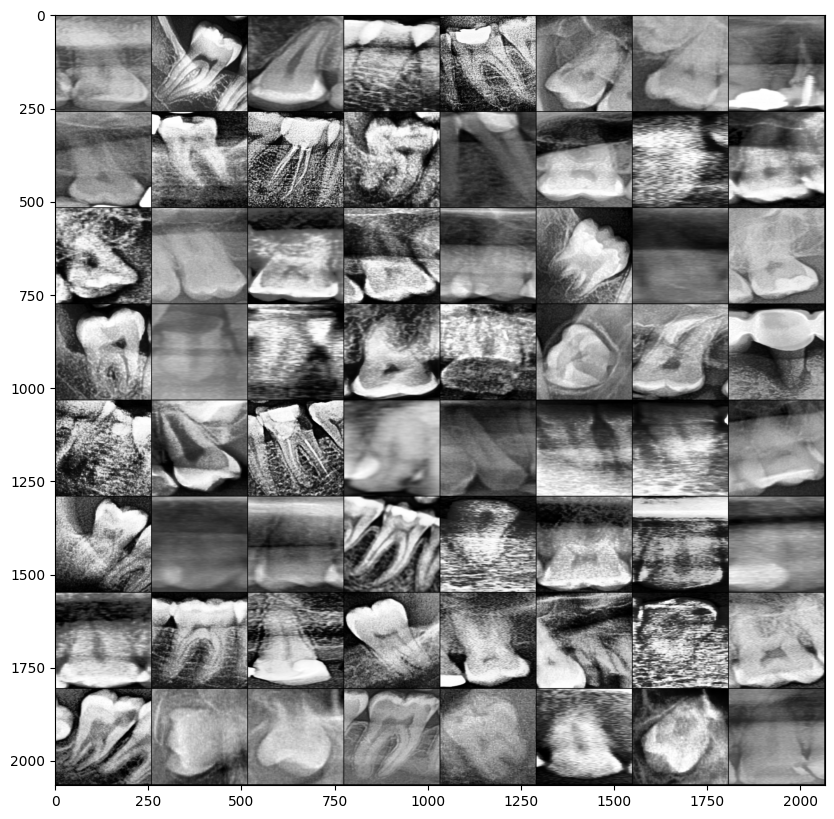

In [10]:
plt.figure(figsize=(16,10))
plt.imshow(make_grid(denorm(next(iter(h_uh_train_dl))[0])).permute(1,2,0))

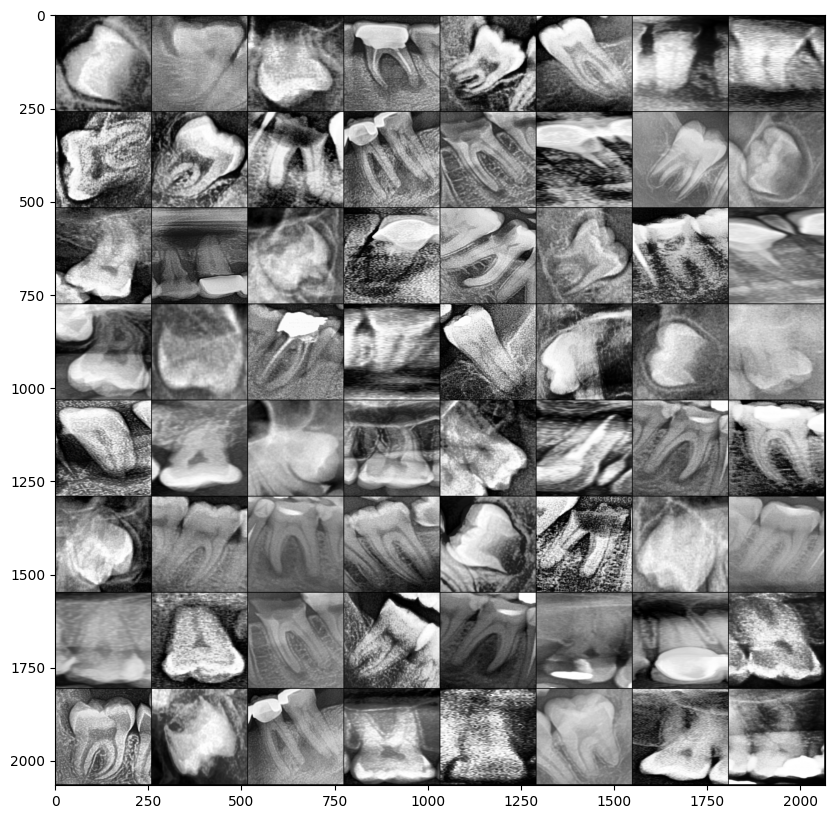

In [11]:
plt.figure(figsize=(16,10))
plt.imshow(make_grid(denorm(next(iter(dis_train_dl))[0])).permute(1,2,0))

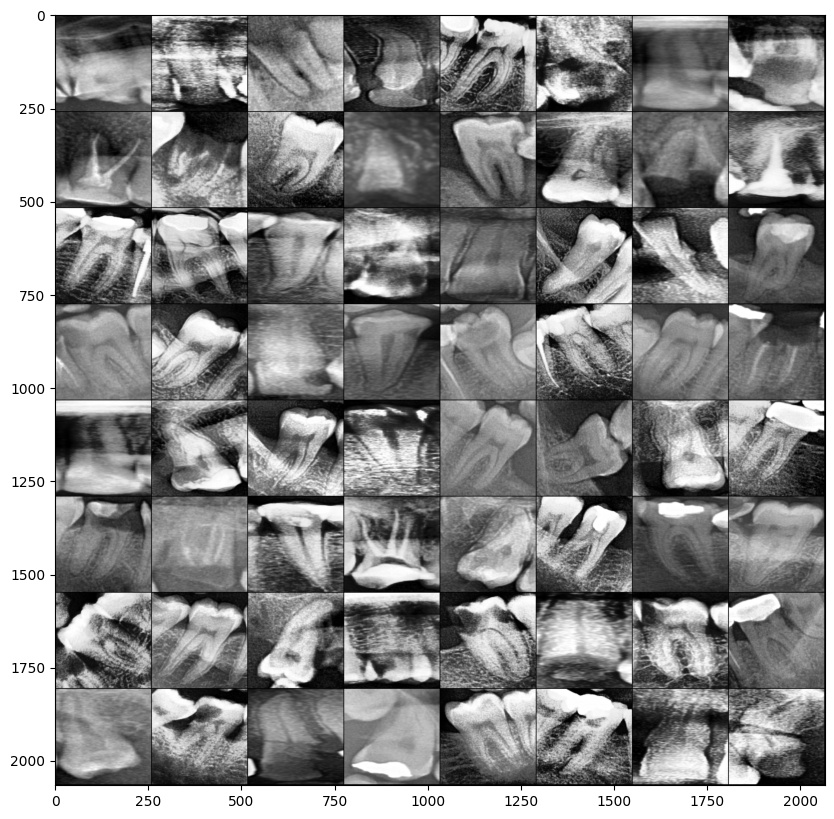

In [12]:
plt.figure(figsize=(16,10))
plt.imshow(make_grid(denorm(next(iter(c_dc_train_dl))[0])).permute(1,2,0))

In [9]:
healthy_unhealthy_classifier, optimizer, scheduler = build_swin_model(num_classes=dis_data_yaml['healthy_unhealthy']['nc'],
                                                                      lr= H_UH_CONFIG['lr'],
                                                                      epochs=H_UH_CONFIG['epochs'],
                                                                      dropout=H_UH_CONFIG['drop_out'],
                                                                      freeze_backbone=True,
                                                                      optimizer_type='SGD',
                                                                      scheduler_type='cosine',
                                                                      unfreeze_layers=['features.1','features.2','features.5','features.6'],
                                                                      )

Model Loaded: SwinV2-T (num_classes=2)
Head Replaced: Linear(in_features=768, out_features=2)
Backbone Frozen: True | Head Trainable: True
Selective Unfreeze Enabled: ['features.1', 'features.2', 'features.5', 'features.6']
Optimizer Loaded: SGD (lr=0.0001, momentum=0.9, weight_decay=0.0001)
Scheduler Loaded: CosineAnnealingLR (T_max=15, eta_min=1e-5)
Model Build Complete


In [ ]:
healthy_unhealthy_classifier, history, best_epoch = train(model=healthy_unhealthy_classifier,
                                                          train_dl=h_uh_train_dl,
                                                          valid_dl=h_uh_valid_dl,
                                                          epochs=H_UH_CONFIG['epochs'],
                                                          criterion=FocalLoss(),
                                                          optimizer=optimizer,
                                                          early_stopping_metric='loss',
                                                          patience=H_UH_CONFIG['patience'],
                                                          scheduler=scheduler,
                                                          device_name=H_UH_CONFIG['device_name'],
                                                          save_dir=os.path.join(stage3_config['paths']['runs_s3_output'],'Healthy & Un-Healthy Classifier','weights')
                                                          )

show_curves(history,
            save_dir=os.path.join(stage3_config['paths']['runs_s3_output'],'Healthy & Un-Healthy Classifier')
            )

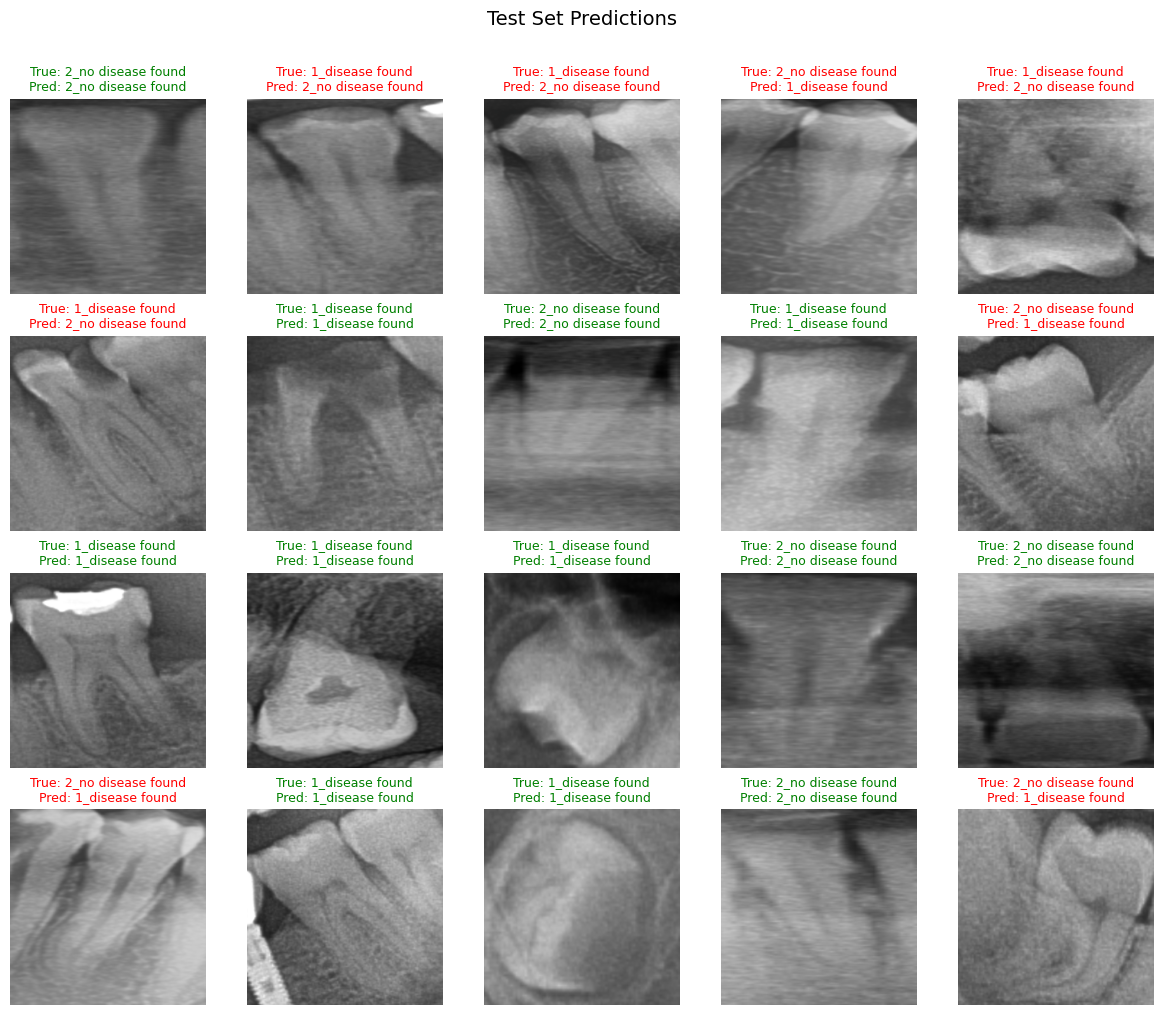

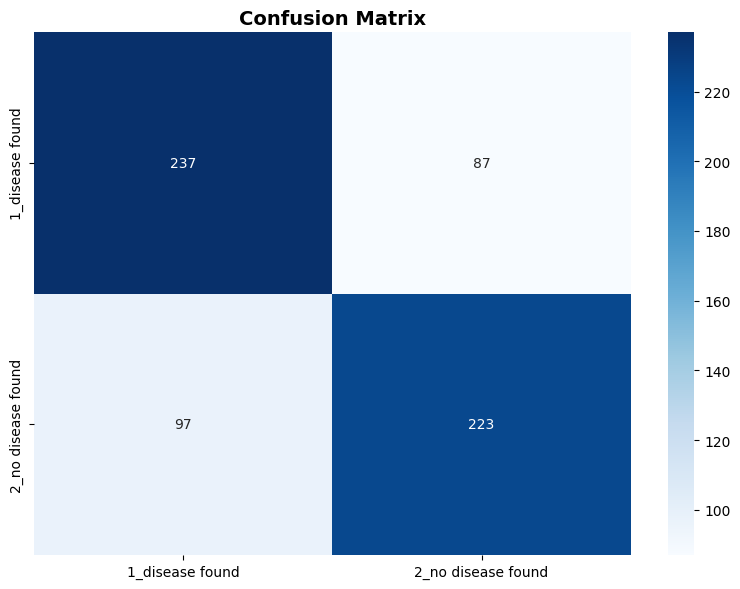

                    precision    recall  f1-score   support

   1_disease found       0.71      0.73      0.72       324
2_no disease found       0.72      0.70      0.71       320

          accuracy                           0.71       644
         macro avg       0.71      0.71      0.71       644
      weighted avg       0.71      0.71      0.71       644



In [14]:
healthy_unhealthy_classifier.load_state_dict(load(trained_models_config['healthy_unhealthy_model']['last'],map_location= device(H_UH_CONFIG['device_name'])))

all_labels, all_preds = predict_classifier(healthy_unhealthy_classifier, h_uh_test_dl, H_UH_CONFIG['device_name'], h_uh_train_dataset.classes,
                                  show_plot=True,
                                  save_plot_path=os.path.join(stage3_config['paths']['runs_s3_output'],'Healthy & Un-Healthy Classifier')
                                  )

show_confusion_matrix(all_labels,all_preds,h_uh_train_dataset.classes,
                      save_dir=os.path.join(stage3_config['paths']['runs_s3_output'],'Healthy & Un-Healthy Classifier')
                      )

In [11]:
disease_classifier, optimizer, scheduler = build_swin_model(dis_data_yaml['disease_classifier']['nc'],
                                                            DIS_CONFIG['lr'],
                                                            DIS_CONFIG['epochs'],
                                                            dropout=DIS_CONFIG['drop_out'],
                                                            freeze_backbone=True,
                                                            optimizer_type='SGD',
                                                            scheduler_type='cosine',
                                                            unfreeze_layers=['features.1','features.2','features.5','features.6'],
                                                            )

Model Loaded: SwinV2-T (num_classes=3)
Head Replaced: Linear(in_features=768, out_features=3)
Backbone Frozen: True | Head Trainable: True
Selective Unfreeze Enabled: ['features.1', 'features.2', 'features.5', 'features.6']
Optimizer Loaded: SGD (lr=0.0001, momentum=0.9, weight_decay=25)
Scheduler Loaded: CosineAnnealingLR (T_max=10, eta_min=1e-5)
Model Build Complete


Epoch: 1: 100%|██████████| 123/123 [01:17<00:00,  1.59it/s]


Train Loss: 0.4136, Valid Loss: 0.3345 | Train Accuracy: 0.5461, Valid Accuracy: 0.6390
Epoch 1: LR = 0.0001
  New best saved - loss: 0.3345


Epoch: 2: 100%|██████████| 123/123 [01:15<00:00,  1.63it/s]


Train Loss: 0.2838, Valid Loss: 0.2612 | Train Accuracy: 0.6921, Valid Accuracy: 0.7234
Epoch 2: LR = 0.0001
  New best saved - loss: 0.2612


Epoch: 3: 100%|██████████| 123/123 [01:17<00:00,  1.59it/s]


...

Train Loss: 0.0733, Valid Loss: 0.1191 | Train Accuracy: 0.9093, Valid Accuracy: 0.8546
Epoch 23: LR = 0.0001
  No improvement (3/7)


Epoch: 24: 100%|██████████| 123/123 [01:13<00:00,  1.68it/s]


Train Loss: 0.0762, Valid Loss: 0.1209 | Train Accuracy: 0.9093, Valid Accuracy: 0.8520
Epoch 24: LR = 0.0001
  No improvement (4/7)


Epoch: 25: 100%|██████████| 123/123 [01:13<00:00,  1.67it/s]


Train Loss: 0.0707, Valid Loss: 0.1105 | Train Accuracy: 0.9159, Valid Accuracy: 0.8728
Epoch 25: LR = 0.0001
  No improvement (5/7)
Best Model Loaded Successfully!


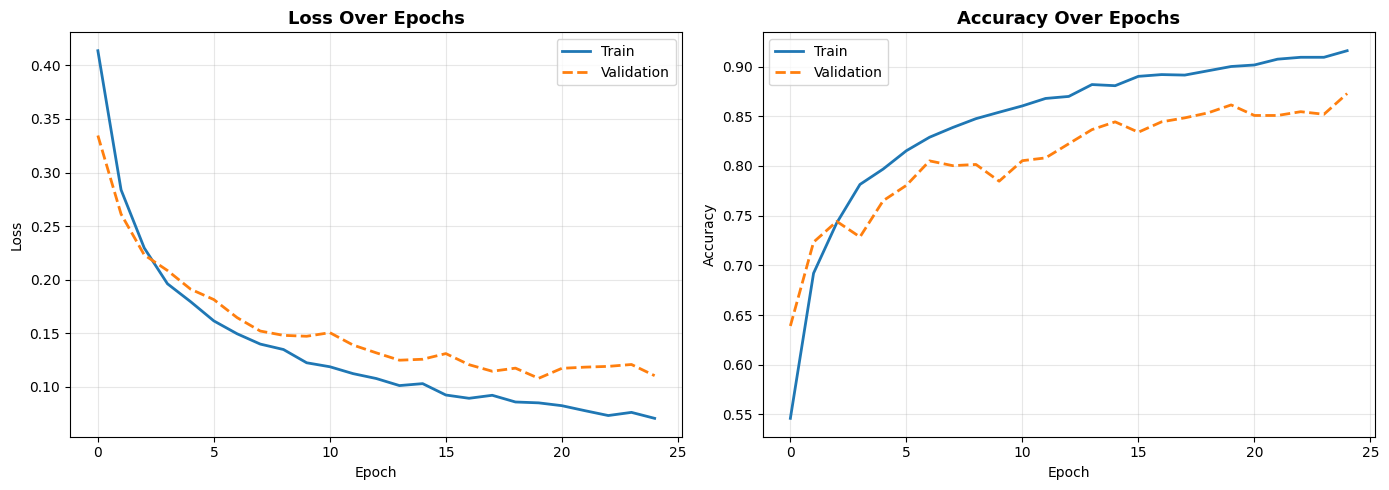

In [ ]:
disease_classifier, history, best_epoch = train(disease_classifier,dis_train_dl,dis_valid_dl,
                                                DIS_CONFIG['epochs'],
                                                FocalLoss(),
                                                optimizer,
                                                early_stopping_metric='loss',
                                                patience=DIS_CONFIG['patience'],
                                                scheduler=scheduler,
                                                device_name=DIS_CONFIG['device_name'],
                                                save_dir=os.path.join(stage3_config['paths']['runs_s3_output'],'Disease Classifier','weights')
                                                )

show_curves(history,
            save_dir=os.path.join(stage3_config['paths']['runs_s3_output'],'Disease Classifier')
            )

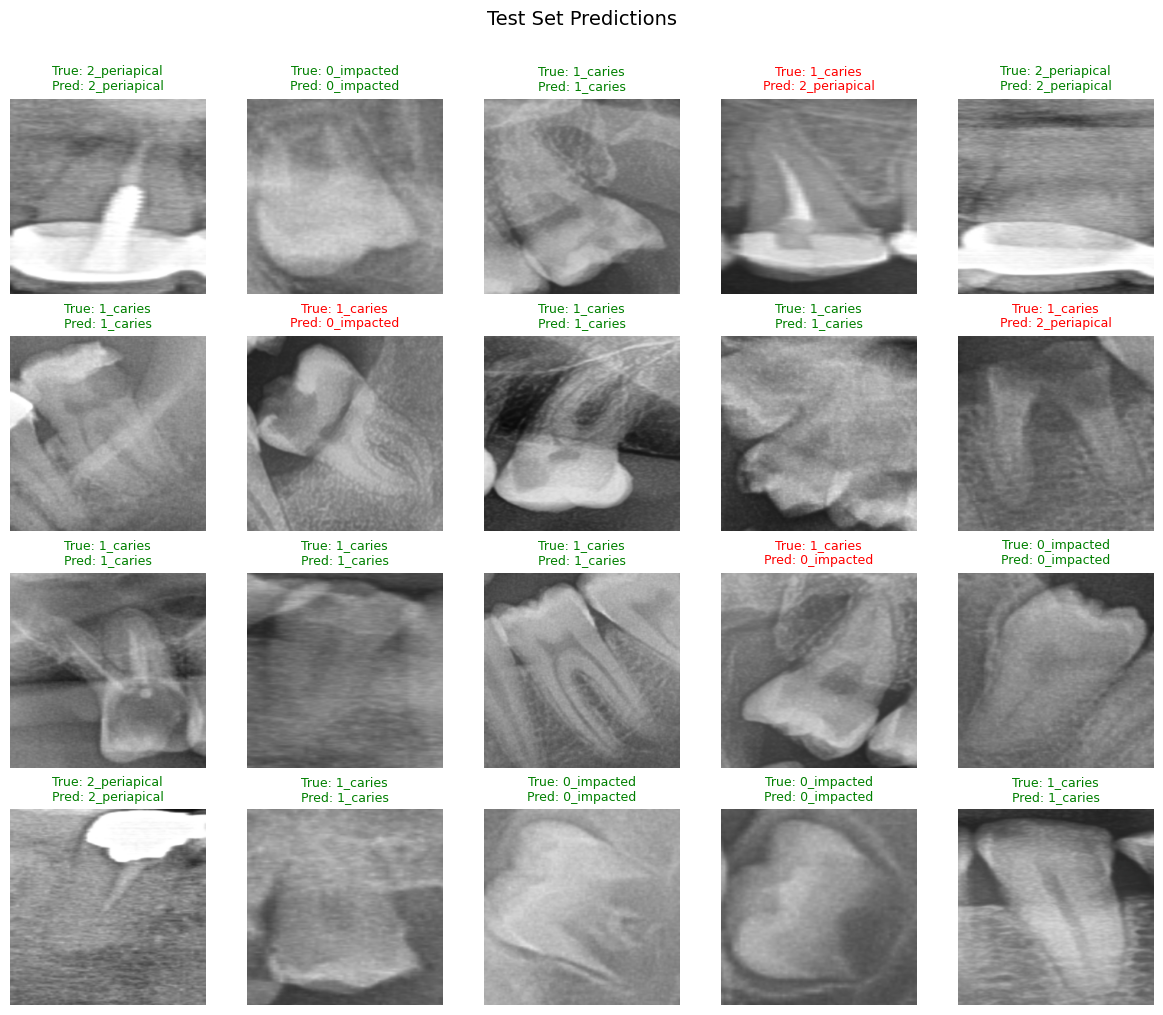

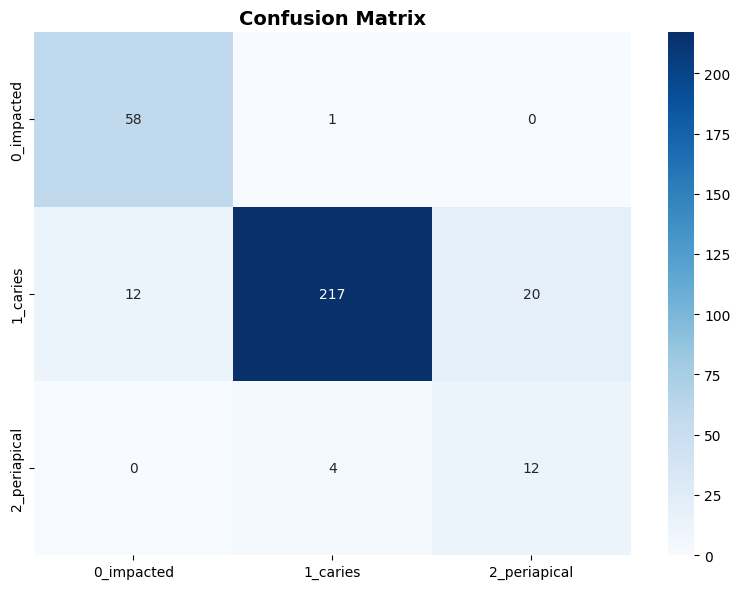

              precision    recall  f1-score   support

  0_impacted       0.83      0.98      0.90        59
    1_caries       0.98      0.87      0.92       249
2_periapical       0.38      0.75      0.50        16

    accuracy                           0.89       324
   macro avg       0.73      0.87      0.77       324
weighted avg       0.92      0.89      0.90       324



In [14]:
disease_classifier.load_state_dict(load(trained_models_config['disease_classification_model']['best'],map_location= device(DIS_CONFIG['device_name'])))

all_labels, all_preds = predict_classifier(disease_classifier, dis_test_dl, DIS_CONFIG['device_name'], dis_train_dataset.classes,
                                  show_plot=True,
                                  save_plot_path=os.path.join(stage3_config['paths']['runs_s3_output'],'Disease Classifier')
                                  )

show_confusion_matrix(all_labels,all_preds,dis_train_dataset.classes,
                      save_dir=os.path.join(stage3_config['paths']['runs_s3_output'],'Disease Classifier')
                      )

In [12]:
caries_deepcaries_classifier, optimizer, scheduler = build_swin_model(dis_data_yaml['caries_or_deepcaries']['nc'],
                                                C_DC_CONFIG['lr'],
                                                epochs=C_DC_CONFIG['epochs'],
                                                dropout=C_DC_CONFIG['drop_out'],
                                                freeze_backbone=True,
                                                optimizer_type='AdamW',
                                                scheduler_type='reduceLROnPlateau',
                                                unfreeze_layers=['features.1','features.2','features.3','features.4','features.5','features.6','features.7'],
                                                )

Model Loaded: SwinV2-T (num_classes=2)
Head Replaced: Linear(in_features=768, out_features=2)
Backbone Frozen: True | Head Trainable: True
Selective Unfreeze Enabled: ['features.1', 'features.2', 'features.3', 'features.4', 'features.5', 'features.6', 'features.7']
Optimizer Loaded: AdamW (lr=0.0001, weight_decay=0.0001)
Scheduler Loaded: ReduceLROnPlateau (mode='min', factor=0.5, patience=1)
Model Build Complete


In [ ]:
caries_deepcaries_classifier, history, best_epoch = train(caries_deepcaries_classifier,c_dc_train_dl,c_dc_valid_dl,
                                                C_DC_CONFIG['epochs'],
                                                FocalLoss(alpha=tensor([1.0, 1.5]).to(device(C_DC_CONFIG['device_name']))),
                                                optimizer,
                                                early_stopping_metric='loss',
                                                patience=C_DC_CONFIG['patience'],
                                                scheduler=scheduler,
                                                device_name=C_DC_CONFIG['device_name'],
                                                save_dir=os.path.join(stage3_config['paths']['runs_s3_output'],'Caries & Deep Caries Classifier','weights'))

show_curves(history,save_dir=os.path.join(stage3_config['paths']['runs_s3_output'],'Caries & Deep Caries Classifier'))

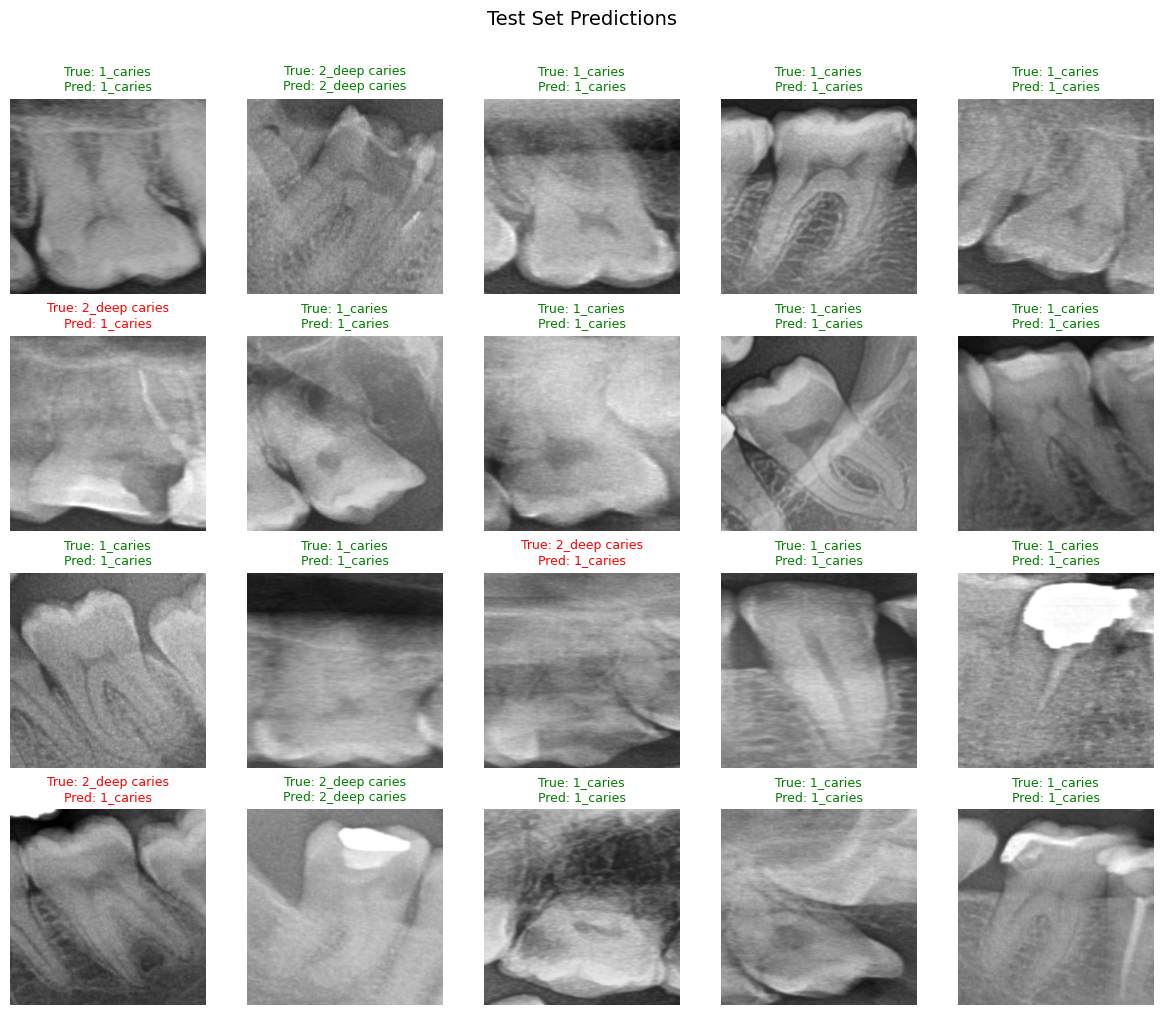

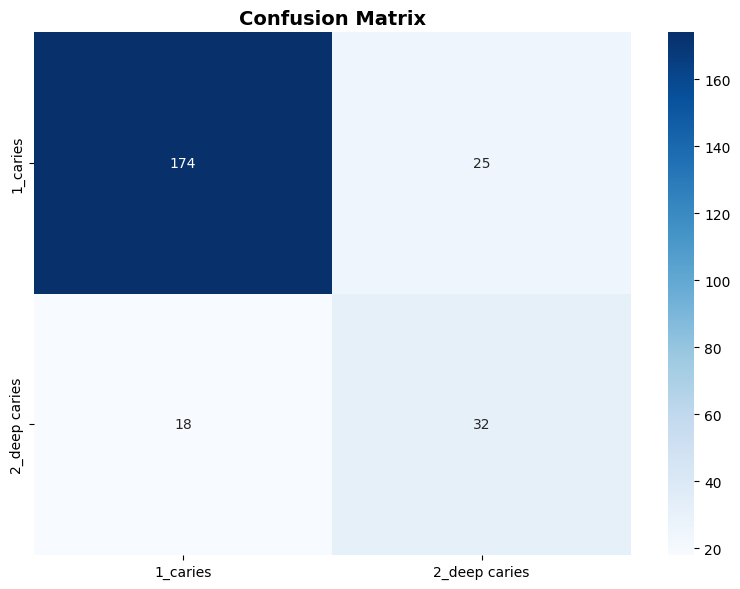

               precision    recall  f1-score   support

     1_caries       0.91      0.87      0.89       199
2_deep caries       0.56      0.64      0.60        50

     accuracy                           0.83       249
    macro avg       0.73      0.76      0.74       249
 weighted avg       0.84      0.83      0.83       249



In [16]:
caries_deepcaries_classifier.load_state_dict(load(trained_models_config['caries_deepcaries_model']['best'],map_location= device(C_DC_CONFIG['device_name'])))

all_labels, all_preds = predict_classifier(caries_deepcaries_classifier, c_dc_test_dl, C_DC_CONFIG['device_name'], c_dc_train_dataset.classes,
                                           show_plot=True,save_plot_path=os.path.join(stage3_config['paths']['runs_s3_output'],'Caries & Deep Caries Classifier'))

show_confusion_matrix(all_labels,all_preds,c_dc_train_dataset.classes,save_dir=os.path.join(stage3_config['paths']['runs_s3_output'],'Caries & Deep Caries Classifier'))